# Import data

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Global style map: label -> {color, marker} for consistent naming and styling across plots
STYLE_MAP = {
    'IncMiner':   {'color': 'C0', 'marker': 'o'},
    'BatchMiner': {'color': 'C1', 'marker': 's'},
    'IncDC':      {'color': 'C2', 'marker': '^'},
}

# Wide figure with legend only (shared across all figures)
from matplotlib.lines import Line2D
fig_legend = plt.figure(figsize=(6, 0.6))
handles = [Line2D([], [], **{**STYLE_MAP[k], 'linestyle': '-'}, label=k) for k in STYLE_MAP]
fig_legend.legend(handles=handles, ncol=3, loc='center', frameon=True)
plt.axis('off')
plt.tight_layout()
plt.show()

In [15]:
# Read all sheets into a dictionary of DataFrames
inc_dc_dfs = pd.read_excel('IncDC-0310.xlsx', sheet_name=None)


# Print the names of the sheets
print(inc_dc_dfs.keys())

dict_keys(['adult varying |ΔD+|', 'airports varying |ΔD+|', 'adult varying |D|', 'airports varying |D|'])


In [16]:
df_adult = pd.read_csv('experiment_results_inc_batch_align_dc_adult.csv')

In [17]:
df_adult

,experiment_type,dataset,origin_size,column_number,scale,scale_size,support,confidence,inc_type,inc_ratio,...,inc_revisit_time_s,inc_expansion_time_s,inc_aff_calculate_time_s,counter_sketch_error_bound,counter_sketch_failure_probability,batch_time_s,batch_rule_number,batch_memory_mb,rule_lhs_max_size,inc_model_retrain_time_s
0,SCALE,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,0.2,6512,212,0.8,add,0.01,...,0.022948,0.000004,16.321379,2.867460e+05,1.221403,2.449822,2776,38.491455,20,1.515682
1,SCALE,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,0.4,13024,424,0.8,add,0.01,...,0.022128,0.000005,19.536046,1.189055e+06,1.221403,4.617023,2915,59.322639,20,1.636435
2,SCALE,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,0.6,19536,636,0.8,add,0.01,...,0.009103,0.000005,21.945746,2.687452e+06,1.221403,7.272086,2948,99.130844,20,1.817989
3,SCALE,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,0.8,26048,848,0.8,add,0.01,...,0.008411,0.000004,23.543862,4.792449e+06,1.221403,9.328999,3008,108.980362,20,1.586889
4,SCALE,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,1060,0.8,add,0.01,...,0.010015,0.000005,24.727249,7.511782e+06,1.221403,11.336651,3042,125.628449,20,1.627106
5,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,1060,0.8,add,0.01,...,0.008511,0.000004,24.599993,7.526723e+06,1.221403,11.558656,3036,129.147194,20,1.731556
6,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,1060,0.8,add,0.05,...,0.019969,0.000005,30.064756,7.532957e+06,1.221403,12.194897,3138,139.616470,20,1.733432
7,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,1060,0.8,add,0.15,...,0.039437,0.000005,44.637474,7.560326e+06,1.221403,15.020043,3297,135.939178,20,1.972903
8,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,1060,0.8,add,0.20,...,0.029284,0.000005,48.095514,7.527145e+06,1.221403,15.644169,3285,130.465912,20,1.734372
9,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,1060,0.8,add,0.30,...,0.012545,0.000007,59.070489,7.502660e+06,1.221403,15.703159,3195,185.270294,20,1.622714


In [18]:
# Separate by experiment_type: SCALE vs ADD
df_adult_scale = df_adult[df_adult['experiment_type'] == 'SCALE'].copy()
df_adult_add = df_adult[df_adult['experiment_type'] == 'ADD'].copy()

In [19]:
# ADD experiments only
df_adult_add

,experiment_type,dataset,origin_size,column_number,scale,scale_size,support,confidence,inc_type,inc_ratio,...,inc_revisit_time_s,inc_expansion_time_s,inc_aff_calculate_time_s,counter_sketch_error_bound,counter_sketch_failure_probability,batch_time_s,batch_rule_number,batch_memory_mb,rule_lhs_max_size,inc_model_retrain_time_s
5,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,1060,0.8,add,0.01,...,0.008511,0.000004,24.599993,7526722.602,1.221403,11.558656,3036,129.147194,20,1.731556
6,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,1060,0.8,add,0.05,...,0.019969,0.000005,30.064756,7532957.205,1.221403,12.194897,3138,139.616470,20,1.733432
7,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,1060,0.8,add,0.15,...,0.039437,0.000005,44.637474,7560325.965,1.221403,15.020043,3297,135.939178,20,1.972903
8,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,1060,0.8,add,0.20,...,0.029284,0.000005,48.095514,7527145.474,1.221403,15.644169,3285,130.465912,20,1.734372
9,ADD,/pv32/incremental-rule-discovery/datasets/adul...,32561,15,1.0,32561,1060,0.8,add,0.30,...,0.012545,0.000007,59.070489,7502659.766,1.221403,15.703159,3195,185.270294,20,1.622714


# Exp-1 Compare with DCs

## Vary $|\Delta D_+|$

In [20]:
inc_dc = inc_dc_dfs['adult varying |ΔD+|']

In [21]:
inc_dc

,数据集,base行数,增量模式,增量比例,增量行数,DC数量,耗时（ms）,备注
0,adult,22792,add,0.01,326,2991,3319,NaN
1,adult,22792,add,0.05,1629,2981,6470,NaN
2,adult,22792,add,0.15,4884,2959,23708,NaN
3,adult,22792,add,0.20,6512,2919,34620,NaN
4,adult,22792,add,0.30,9769,2956,71932,NaN


<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
/var/folders/mv/j_58gf917nd0c2nczfjyc3900000gn/T/ipykernel_75427/81448902.py:8: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel('Increment ratio ($|\Delta D_+| / |D|$)')


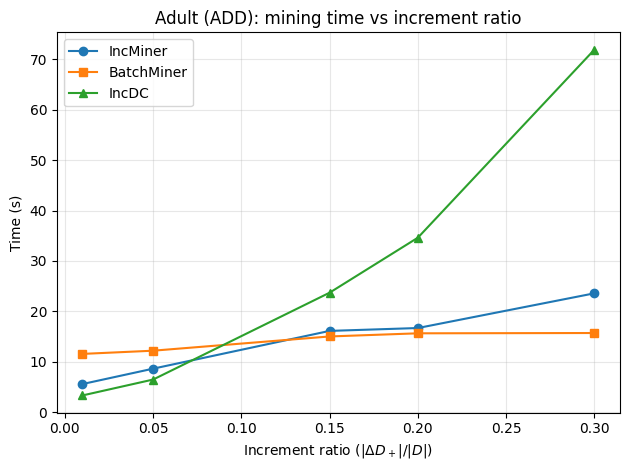

In [22]:
# Extract the three columns: inc_ratio (x), inc_time_s and batch_time_s (mining times)
plot_df = df_adult_add[['inc_ratio', 'inc_time_s', 'batch_time_s']].sort_values('inc_ratio')

fig, ax = plt.subplots()
ax.plot(plot_df['inc_ratio'], plot_df['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(plot_df['inc_ratio'], plot_df['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(inc_dc['增量比例'], inc_dc['耗时（ms）'] / 1000, label='IncDC', **STYLE_MAP['IncDC'])
ax.set_xlabel('Increment ratio ($|\Delta D_+| / |D|$)')
ax.set_ylabel('Time (s)')
ax.set_title('Adult (ADD): mining time vs increment ratio')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Other experiment results: Airports

In [ ]:
# Read airports CSV and split by experiment_type (SCALE vs ADD); keep ADD only
df_airports = pd.read_csv('experiment_results_inc_batch_align_dc_airports.csv')
df_airports_add = df_airports[df_airports['experiment_type'] == 'ADD'].copy()

# Extract inc_ratio and times for IncMiner and BatchMiner (same as adult)
plot_df_airports = df_airports_add[['inc_ratio', 'inc_time_s', 'batch_time_s']].sort_values('inc_ratio')
plot_df_airports

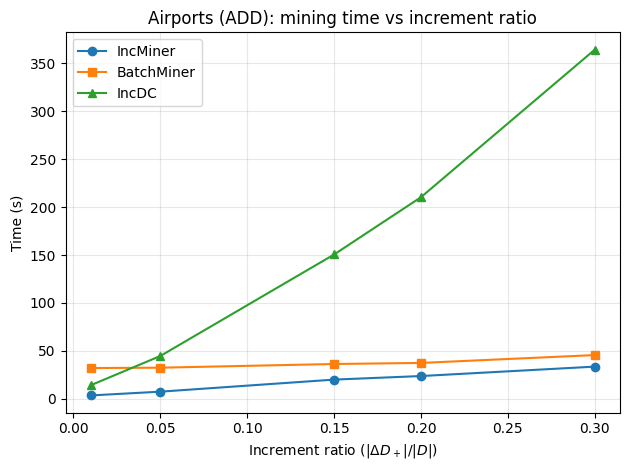

In [13]:
# IncDC DataFrame: airports varying |ΔD+|
inc_dc_airports = inc_dc_dfs['airports varying |ΔD+|']

# Same plot as adult: IncMiner, BatchMiner, IncDC (IncDC time 耗时 ms -> s)
fig, ax = plt.subplots()
ax.plot(plot_df_airports['inc_ratio'], plot_df_airports['inc_time_s'], label='IncMiner', **STYLE_MAP['IncMiner'])
ax.plot(plot_df_airports['inc_ratio'], plot_df_airports['batch_time_s'], label='BatchMiner', **STYLE_MAP['BatchMiner'])
ax.plot(inc_dc_airports['增量比例'], inc_dc_airports['耗时（ms）'] / 1000, label='IncDC', **STYLE_MAP['IncDC'])
ax.set_xlabel('Increment ratio ($|\\Delta D_+| / |D|$)')
ax.set_ylabel('Time (s)')
ax.set_title('Airports (ADD): mining time vs increment ratio')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Rule count comparison: IncMiner vs IncDC (aligned by dataset and inc_ratio)

In [15]:
# Align on same dataset and inc_ratio; compare IncMiner rule count vs IncDC (DC数量).
# Expect: IncMiner >= IncDC (rules mined at least as many as DCs).

def compare_rules(inc_add_df, inc_dc_df, dataset_name):
    """inc_add_df: ADD rows with inc_ratio, inc_rule_number, batch_rule_number. inc_dc_df: 增量比例, DC数量."""
    inc = inc_add_df[['inc_ratio', 'inc_rule_number', 'batch_rule_number']].sort_values('inc_ratio').rename(
        columns={'inc_rule_number': 'IncMiner', 'batch_rule_number': 'BatchMiner'})
    dc = inc_dc_df[['增量比例', 'DC数量']].rename(columns={'增量比例': 'inc_ratio', 'DC数量': 'IncDC'})
    # align by inc_ratio (float)
    m = inc.merge(dc, on='inc_ratio', how='inner')
    m.insert(0, 'dataset', dataset_name)
    m['IncMiner >= IncDC'] = m['IncMiner'] >= m['IncDC']
    return m

adult_cmp = compare_rules(df_adult_add, inc_dc, 'adult')
airports_cmp = compare_rules(df_airports_add, inc_dc_airports, 'airports')
rule_comparison = pd.concat([adult_cmp, airports_cmp], ignore_index=True)
print('IncMiner >= IncDC for all rows:', rule_comparison['IncMiner >= IncDC'].all())
rule_comparison

IncMiner >= IncDC for all rows: False


,dataset,inc_ratio,IncMiner,BatchMiner,IncDC,IncMiner >= IncDC
0,adult,0.01,2433,3036,2991,False
1,adult,0.05,2399,3138,2981,False
2,adult,0.15,2503,3297,2959,False
3,adult,0.20,2402,3285,2919,False
4,adult,0.30,2254,3195,2956,False
5,airports,0.01,1150,2425,2596,False
6,airports,0.05,1202,2575,2657,False
7,airports,0.15,1210,2709,2644,False
8,airports,0.20,1188,2714,2621,False
9,airports,0.30,1125,3425,2957,False
